# Hypothesis Testing Theory & Application
## Gull Aircraft Strike Analysis

This notebook provides comprehensive theoretical foundations and practical implementations for three key hypothesis testing techniques:

1. **Chi-Square Test of Independence** - Testing relationships between categorical variables
2. **Two-Proportion Z-Test** - Comparing proportions between two groups
3. **Chi-Square Goodness-of-Fit Test** - Testing if observed data matches an expected distribution

---

## Table of Contents

1. [Setup & Data Loading](#setup)
2. [Chi-Square Test of Independence](#chi-square-independence)
   - Theory & Mathematical Foundation
   - Assumptions & Conditions
   - Application: Flight Phase vs Damage
   - Interpretation Guide
3. [Two-Proportion Z-Test](#two-proportion)
   - Theory & Mathematical Foundation
   - Assumptions & Conditions
   - Application: EN ROUTE vs APPROACH Damage Rates
   - Interpretation Guide
4. [Chi-Square Goodness-of-Fit Test](#goodness-of-fit)
   - Theory & Mathematical Foundation
   - Assumptions & Conditions
   - Application: Geographic and Seasonal Distributions
   - Interpretation Guide
5. [Summary & Recommendations](#summary)

<a id='setup'></a>
## 1. Setup & Data Loading

In [1]:
from pathlib import Path
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, chisquare, norm
from statsmodels.stats.proportion import proportions_ztest

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load gull strike data
DATA_DIR = Path.cwd().parent / 'data' if Path.cwd().name == 'notebooks' else Path.cwd() / 'data'
csv_path = DATA_DIR / 'wildlife-strikes' / 'database.csv'

if not csv_path.exists():
    raise FileNotFoundError(f'Expected dataset at {csv_path}. Run notebooks/download_wildlife.ipynb first.')

# Load and filter for gull strikes
lazy_df = pl.scan_csv(
    csv_path,
    ignore_errors=True,
    infer_schema_length=2000,
    null_values=['', ' ', 'NA', 'UNKNOWN'],
)

# Create damage flag
damage_lazy = lazy_df.with_columns(
    pl.col('Aircraft Damage')
    .cast(pl.Float64, strict=False)
    .fill_null(0)
    .clip(0, 1)
    .alias('damage_flag')
)

# Filter for gulls
gull_df = (
    damage_lazy
    .filter(pl.col('Species Name').str.to_lowercase().str.contains('gull'))
    .collect()
)

gull_pd = gull_df.to_pandas()
gull_pd['damage_flag'] = gull_pd['damage_flag'].astype(int)

print(f"Total gull strikes: {len(gull_pd):,}")
print(f"Overall damage rate: {gull_pd['damage_flag'].mean():.2%}")
print(f"\nDataset shape: {gull_pd.shape}")
print(f"\nKey columns available: {', '.join(gull_pd.columns[:10])}...")

Total gull strikes: 10,584
Overall damage rate: 13.73%

Dataset shape: (10584, 67)

Key columns available: Record ID, Incident Year, Incident Month, Incident Day, Operator ID, Operator, Aircraft, Aircraft Type, Aircraft Make, Aircraft Model...


---
<a id='chi-square-independence'></a>
## 2. Chi-Square Test of Independence

### Theory & Mathematical Foundation

The **Chi-Square Test of Independence** determines whether two categorical variables are independent or associated.

#### Hypotheses
- **H₀ (Null Hypothesis)**: The two variables are independent (no association)
- **H₁ (Alternative Hypothesis)**: The two variables are dependent (there is an association)

#### Test Statistic

The chi-square statistic is calculated as:

$$\chi^2 = \sum_{i=1}^{r} \sum_{j=1}^{c} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$

Where:
- $O_{ij}$ = Observed frequency in cell (i,j)
- $E_{ij}$ = Expected frequency in cell (i,j) under independence
- $r$ = number of rows
- $c$ = number of columns

#### Expected Frequencies

Under the null hypothesis of independence:

$$E_{ij} = \frac{(\text{Row}_i \text{ Total}) \times (\text{Column}_j \text{ Total})}{\text{Grand Total}}$$

#### Degrees of Freedom

$$df = (r - 1) \times (c - 1)$$

#### Distribution

Under H₀, the test statistic follows a chi-square distribution with $(r-1)(c-1)$ degrees of freedom.

### Assumptions & Conditions

1. **Independence of Observations**: Each observation must be independent
2. **Expected Cell Frequencies**: At least 80% of cells should have expected frequencies ≥ 5
3. **No Cell with Zero Expected Count**: All expected frequencies should be > 0
4. **Categorical Variables**: Both variables must be categorical
5. **Sample Size**: Generally, n ≥ 20 and all expected counts ≥ 1

### Interpretation Guide

- **p-value < α (typically 0.05)**: Reject H₀ → Variables are associated
- **p-value ≥ α**: Fail to reject H₀ → Insufficient evidence for association
- **Effect Size (Cramér's V)**: 
  - V = 0: No association
  - V = 0.1: Small association
  - V = 0.3: Medium association  
  - V = 0.5: Large association

$$V = \sqrt{\frac{\chi^2}{n \times (k-1)}}$$

where $k = \min(r, c)$

### Application: Flight Phase vs Damage

**Research Question**: Is aircraft damage independent of the flight phase during which a gull strike occurs?

**Hypotheses**:
- **H₀**: Damage occurrence is independent of flight phase
- **H₁**: Damage occurrence depends on flight phase (certain phases are more dangerous)

In [3]:
# Create contingency table
contingency_table = pd.crosstab(
    gull_pd['Flight Phase'].fillna('UNKNOWN'),
    gull_pd['damage_flag'],
    margins=True
)

# Rename columns for clarity
contingency_table.columns = ['No Damage', 'Damage', 'Total']
contingency_table.index.name = 'Flight Phase'

print("Contingency Table: Flight Phase vs Damage")
print("="*60)
print(contingency_table)
print("\n")

# Calculate damage rates by phase
damage_rates = gull_pd.groupby('Flight Phase')['damage_flag'].agg(['sum', 'count', 'mean'])
damage_rates.columns = ['Damage Events', 'Total Strikes', 'Damage Rate']
damage_rates = damage_rates.sort_values('Damage Rate', ascending=False)
print("\nDamage Rates by Flight Phase:")
print("="*60)
print(damage_rates)

Contingency Table: Flight Phase vs Damage
              No Damage  Damage  Total
Flight Phase                          
APPROACH           2242     458   2700
ARRIVAL               1       0      1
CLIMB              1014     414   1428
DEPARTURE            11       1     12
DESCENT              45      21     66
EN ROUTE             51      93    144
LANDING               9       0      9
LANDING ROLL       1284     102   1386
LOCAL                 8       0      8
PARKED               16       0     16
TAKEOFF RUN        1649     334   1983
TAXI                 28       0     28
UNKNOWN            2773      30   2803
All                9131    1453  10584



Damage Rates by Flight Phase:
              Damage Events  Total Strikes  Damage Rate
Flight Phase                                           
EN ROUTE                 93            144       0.6458
DESCENT                  21             66       0.3182
CLIMB                   414           1428       0.2899
APPROACH             

In [4]:
# Perform Chi-Square Test
# Remove margins for the test
observed = pd.crosstab(
    gull_pd['Flight Phase'].fillna('UNKNOWN'),
    gull_pd['damage_flag']
)

chi2_stat, p_value, dof, expected_freq = chi2_contingency(observed)

# Calculate Cramér's V
n = observed.sum().sum()
k = min(observed.shape)
cramers_v = np.sqrt(chi2_stat / (n * (k - 1)))

print("Chi-Square Test Results: Flight Phase vs Damage")
print("="*60)
print(f"Chi-Square Statistic (χ²): {chi2_stat:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p_value:.6f}")
print(f"Cramér's V (Effect Size): {cramers_v:.4f}")
print(f"\nSample Size: {n:,}")
print(f"\nInterpretation:")
if p_value < 0.05:
    print(f"  ✓ Reject H₀ (p < 0.05)")
    print(f"  ✓ There IS a statistically significant association between flight phase and damage")
else:
    print(f"  ✗ Fail to reject H₀ (p ≥ 0.05)")
    print(f"  ✗ No significant association detected")

if cramers_v < 0.1:
    effect = "negligible"
elif cramers_v < 0.3:
    effect = "small"
elif cramers_v < 0.5:
    effect = "medium"
else:
    effect = "large"

print(f"  Effect size is {effect} (V = {cramers_v:.4f})")

Chi-Square Test Results: Flight Phase vs Damage
Chi-Square Statistic (χ²): 1090.5052
Degrees of Freedom: 12
P-value: 0.000000
Cramér's V (Effect Size): 0.3210

Sample Size: 10,584

Interpretation:
  ✓ Reject H₀ (p < 0.05)
  ✓ There IS a statistically significant association between flight phase and damage
  Effect size is medium (V = 0.3210)


In [5]:
# Check assumptions: Expected frequencies
expected_df = pd.DataFrame(
    expected_freq,
    index=observed.index,
    columns=observed.columns
)

print("\nAssumption Check: Expected Frequencies")
print("="*60)
print("\nExpected Frequencies Table:")
print(expected_df)

cells_below_5 = (expected_df < 5).sum().sum()
total_cells = expected_df.size
percent_below_5 = (cells_below_5 / total_cells) * 100

print(f"\nCells with expected frequency < 5: {cells_below_5} out of {total_cells} ({percent_below_5:.1f}%)")
print(f"Minimum expected frequency: {expected_df.min().min():.2f}")

if percent_below_5 <= 20 and expected_df.min().min() >= 1:
    print("\n✓ Assumptions SATISFIED: Test results are reliable")
else:
    print("\n⚠ WARNING: Assumptions may be violated. Consider:")
    print("  - Combining categories with low counts")
    print("  - Using Fisher's Exact Test for small samples")


Assumption Check: Expected Frequencies

Expected Frequencies Table:
damage_flag           0         1
Flight Phase                     
APPROACH      2329.3367  370.6633
ARRIVAL          0.8627    0.1373
CLIMB         1231.9603  196.0397
DEPARTURE       10.3526    1.6474
DESCENT         56.9393    9.0607
EN ROUTE       124.2313   19.7687
LANDING          7.7645    1.2355
LANDING ROLL  1195.7262  190.2738
LOCAL            6.9017    1.0983
PARKED          13.8035    2.1965
TAKEOFF RUN   1710.7684  272.2316
TAXI            24.1561    3.8439
UNKNOWN       2418.1966  384.8034

Cells with expected frequency < 5: 7 out of 26 (26.9%)
Minimum expected frequency: 0.14

⚠ WARNING: Assumptions may be violated. Consider:
  - Combining categories with low counts
  - Using Fisher's Exact Test for small samples


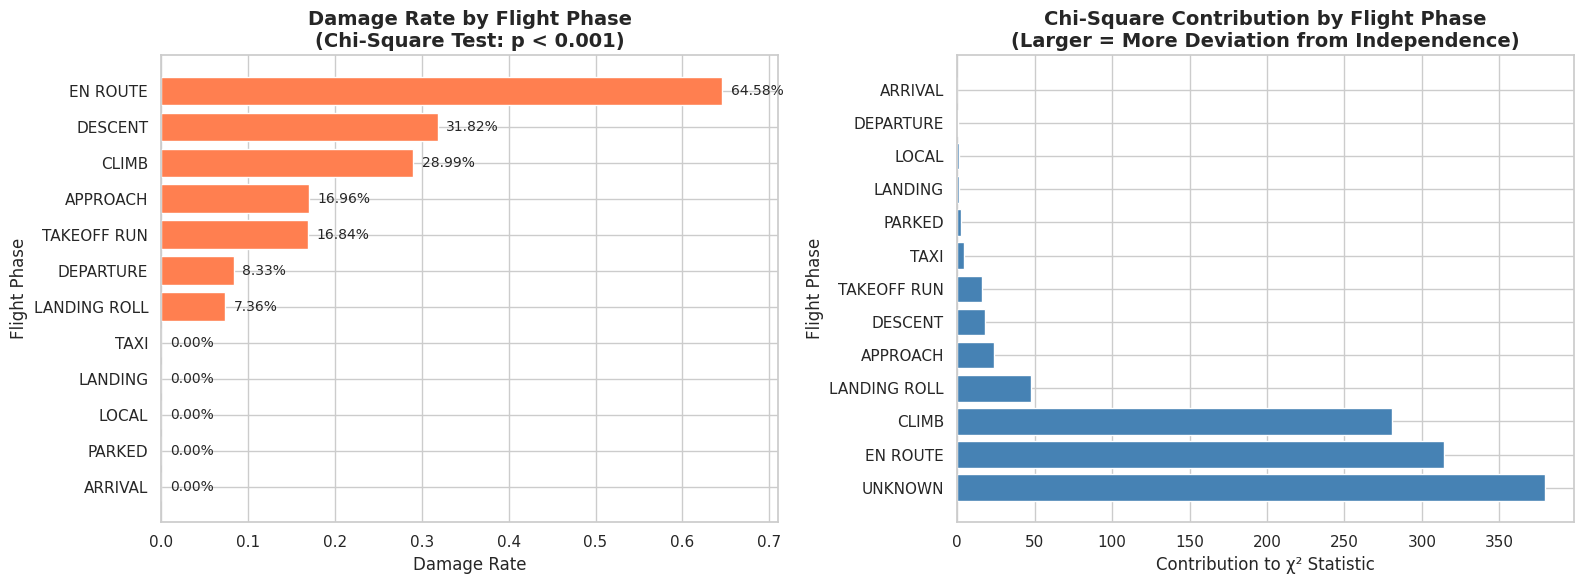


Key Insight: EN ROUTE shows the highest damage rate (64.58%)
while having a relatively high chi-square contribution.


In [6]:
# Visualize the relationship
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Damage rates by flight phase
damage_rates_sorted = damage_rates.sort_values('Damage Rate', ascending=True)
axes[0].barh(damage_rates_sorted.index, damage_rates_sorted['Damage Rate'], color='coral')
axes[0].set_xlabel('Damage Rate', fontsize=12)
axes[0].set_ylabel('Flight Phase', fontsize=12)
axes[0].set_title('Damage Rate by Flight Phase\n(Chi-Square Test: p < 0.001)', fontsize=14, fontweight='bold')
axes[0].set_xlim(0, max(damage_rates_sorted['Damage Rate']) * 1.1)

# Add value labels
for i, v in enumerate(damage_rates_sorted['Damage Rate']):
    axes[0].text(v + 0.01, i, f'{v:.2%}', va='center', fontsize=10)

# Plot 2: Observed vs Expected (Chi-Square contribution)
# Calculate chi-square contribution per cell
chi_contrib = (observed - expected_df)**2 / expected_df
chi_contrib_phase = chi_contrib.sum(axis=1).sort_values(ascending=False)

axes[1].barh(chi_contrib_phase.index, chi_contrib_phase.values, color='steelblue')
axes[1].set_xlabel('Contribution to χ² Statistic', fontsize=12)
axes[1].set_ylabel('Flight Phase', fontsize=12)
axes[1].set_title('Chi-Square Contribution by Flight Phase\n(Larger = More Deviation from Independence)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nKey Insight: EN ROUTE shows the highest damage rate ({damage_rates.loc['EN ROUTE', 'Damage Rate']:.2%})")
print(f"while having a relatively high chi-square contribution.")

---
<a id='two-proportion'></a>
## 3. Two-Proportion Z-Test

### Theory & Mathematical Foundation

The **Two-Proportion Z-Test** compares the proportions of successes between two independent groups to determine if they differ significantly.

#### Hypotheses
- **H₀ (Null Hypothesis)**: $p_1 = p_2$ (proportions are equal)
- **H₁ (Alternative Hypothesis)**: 
  - Two-tailed: $p_1 \neq p_2$ (proportions differ)
  - One-tailed: $p_1 > p_2$ or $p_1 < p_2$

#### Test Statistic

$$z = \frac{\hat{p}_1 - \hat{p}_2}{SE_{pooled}}$$

Where:
- $\hat{p}_1 = \frac{x_1}{n_1}$ = sample proportion in group 1
- $\hat{p}_2 = \frac{x_2}{n_2}$ = sample proportion in group 2
- $x_i$ = number of successes in group i
- $n_i$ = sample size in group i

#### Pooled Standard Error

Under H₀, we pool the data to estimate the common proportion:

$$\hat{p}_{pooled} = \frac{x_1 + x_2}{n_1 + n_2}$$

$$SE_{pooled} = \sqrt{\hat{p}_{pooled}(1-\hat{p}_{pooled})\left(\frac{1}{n_1} + \frac{1}{n_2}\right)}$$

#### Distribution

Under H₀, the test statistic follows a standard normal distribution: $z \sim N(0, 1)$

### Assumptions & Conditions

1. **Independence Within Groups**: Observations within each group are independent
2. **Independence Between Groups**: The two groups are independent of each other
3. **Sample Size**: 
   - $n_1\hat{p}_1 \geq 10$ and $n_1(1-\hat{p}_1) \geq 10$
   - $n_2\hat{p}_2 \geq 10$ and $n_2(1-\hat{p}_2) \geq 10$
4. **Random Sampling**: Data should come from random or representative samples

### Interpretation Guide

- **p-value < α**: Reject H₀ → Proportions are significantly different
- **p-value ≥ α**: Fail to reject H₀ → Insufficient evidence of difference
- **95% Confidence Interval for Difference**: $(\hat{p}_1 - \hat{p}_2) \pm 1.96 \times SE$
- **Effect Size**: Absolute difference $|\hat{p}_1 - \hat{p}_2|$ or relative risk ratio $\frac{\hat{p}_1}{\hat{p}_2}$

### Application: EN ROUTE vs APPROACH Damage Rates

**Research Question**: Do gull strikes during EN ROUTE flight have a different damage rate compared to APPROACH?

Based on our earlier analysis:
- EN ROUTE showed ~64.58% damage rate
- APPROACH showed ~16.96% damage rate

**Hypotheses**:
- **H₀**: $p_{EN\_ROUTE} = p_{APPROACH}$ (damage rates are equal)
- **H₁**: $p_{EN\_ROUTE} \neq p_{APPROACH}$ (damage rates differ)

In [7]:
# Extract data for EN ROUTE and APPROACH
en_route_data = gull_pd[gull_pd['Flight Phase'] == 'EN ROUTE']
approach_data = gull_pd[gull_pd['Flight Phase'] == 'APPROACH']

# Calculate statistics
n1 = len(en_route_data)
x1 = en_route_data['damage_flag'].sum()
p1_hat = x1 / n1

n2 = len(approach_data)
x2 = approach_data['damage_flag'].sum()
p2_hat = x2 / n2

print("Sample Statistics")
print("="*60)
print(f"\nEN ROUTE:")
print(f"  Sample size (n₁): {n1}")
print(f"  Damage events (x₁): {x1}")
print(f"  Sample proportion (p̂₁): {p1_hat:.4f} ({p1_hat:.2%})")

print(f"\nAPPROACH:")
print(f"  Sample size (n₂): {n2}")
print(f"  Damage events (x₂): {x2}")
print(f"  Sample proportion (p̂₂): {p2_hat:.4f} ({p2_hat:.2%})")

print(f"\nDifference in proportions: {p1_hat - p2_hat:.4f} ({(p1_hat - p2_hat):.2%})")
print(f"Relative risk: {p1_hat / p2_hat:.2f}x")
print(f"  (EN ROUTE is {p1_hat / p2_hat:.2f} times more likely to cause damage)")

Sample Statistics

EN ROUTE:
  Sample size (n₁): 144
  Damage events (x₁): 93
  Sample proportion (p̂₁): 0.6458 (64.58%)

APPROACH:
  Sample size (n₂): 2700
  Damage events (x₂): 458
  Sample proportion (p̂₂): 0.1696 (16.96%)

Difference in proportions: 0.4762 (47.62%)
Relative risk: 3.81x
  (EN ROUTE is 3.81 times more likely to cause damage)


In [8]:
# Check assumptions
print("\nAssumption Check: Sample Size Conditions")
print("="*60)
print(f"\nEN ROUTE:")
print(f"  n₁ × p̂₁ = {n1 * p1_hat:.1f} {'✓ ≥ 10' if n1 * p1_hat >= 10 else '✗ < 10'}")
print(f"  n₁ × (1-p̂₁) = {n1 * (1-p1_hat):.1f} {'✓ ≥ 10' if n1 * (1-p1_hat) >= 10 else '✗ < 10'}")

print(f"\nAPPROACH:")
print(f"  n₂ × p̂₂ = {n2 * p2_hat:.1f} {'✓ ≥ 10' if n2 * p2_hat >= 10 else '✗ < 10'}")
print(f"  n₂ × (1-p̂₂) = {n2 * (1-p2_hat):.1f} {'✓ ≥ 10' if n2 * (1-p2_hat) >= 10 else '✗ < 10'}")

all_conditions = (
    n1 * p1_hat >= 10 and n1 * (1-p1_hat) >= 10 and
    n2 * p2_hat >= 10 and n2 * (1-p2_hat) >= 10
)

if all_conditions:
    print("\n✓ All conditions SATISFIED: Normal approximation is valid")
else:
    print("\n⚠ WARNING: Some conditions not met. Consider Fisher's Exact Test.")


Assumption Check: Sample Size Conditions

EN ROUTE:
  n₁ × p̂₁ = 93.0 ✓ ≥ 10
  n₁ × (1-p̂₁) = 51.0 ✓ ≥ 10

APPROACH:
  n₂ × p̂₂ = 458.0 ✓ ≥ 10
  n₂ × (1-p̂₂) = 2242.0 ✓ ≥ 10

✓ All conditions SATISFIED: Normal approximation is valid


In [9]:
# Perform Two-Proportion Z-Test
z_stat, p_value = proportions_ztest([x1, x2], [n1, n2], alternative='two-sided')

# Calculate pooled proportion and standard error manually for demonstration
p_pooled = (x1 + x2) / (n1 + n2)
se_pooled = np.sqrt(p_pooled * (1 - p_pooled) * (1/n1 + 1/n2))

# Calculate 95% confidence interval for difference
se_unpooled = np.sqrt(p1_hat*(1-p1_hat)/n1 + p2_hat*(1-p2_hat)/n2)
margin_of_error = 1.96 * se_unpooled
ci_lower = (p1_hat - p2_hat) - margin_of_error
ci_upper = (p1_hat - p2_hat) + margin_of_error

print("\nTwo-Proportion Z-Test Results")
print("="*60)
print(f"\nPooled proportion (p̂ₚₒₒₗₑₐ): {p_pooled:.4f}")
print(f"Pooled standard error: {se_pooled:.4f}")
print(f"\nZ-statistic: {z_stat:.4f}")
print(f"P-value (two-tailed): {p_value:.6f}")
print(f"\n95% Confidence Interval for (p₁ - p₂):")
print(f"  [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"  [{ci_lower:.2%}, {ci_upper:.2%}]")

print(f"\nInterpretation (α = 0.05):")
if p_value < 0.05:
    print(f"  ✓ Reject H₀ (p = {p_value:.6f} < 0.05)")
    print(f"  ✓ There IS a statistically significant difference in damage rates")
    print(f"  ✓ EN ROUTE damage rate ({p1_hat:.2%}) is significantly higher than APPROACH ({p2_hat:.2%})")
else:
    print(f"  ✗ Fail to reject H₀ (p = {p_value:.6f} ≥ 0.05)")
    print(f"  ✗ No significant difference detected")


Two-Proportion Z-Test Results

Pooled proportion (p̂ₚₒₒₗₑₐ): 0.1937
Pooled standard error: 0.0338

Z-statistic: 14.0878
P-value (two-tailed): 0.000000

95% Confidence Interval for (p₁ - p₂):
  [0.3968, 0.5556]
  [39.68%, 55.56%]

Interpretation (α = 0.05):
  ✓ Reject H₀ (p = 0.000000 < 0.05)
  ✓ There IS a statistically significant difference in damage rates
  ✓ EN ROUTE damage rate (64.58%) is significantly higher than APPROACH (16.96%)


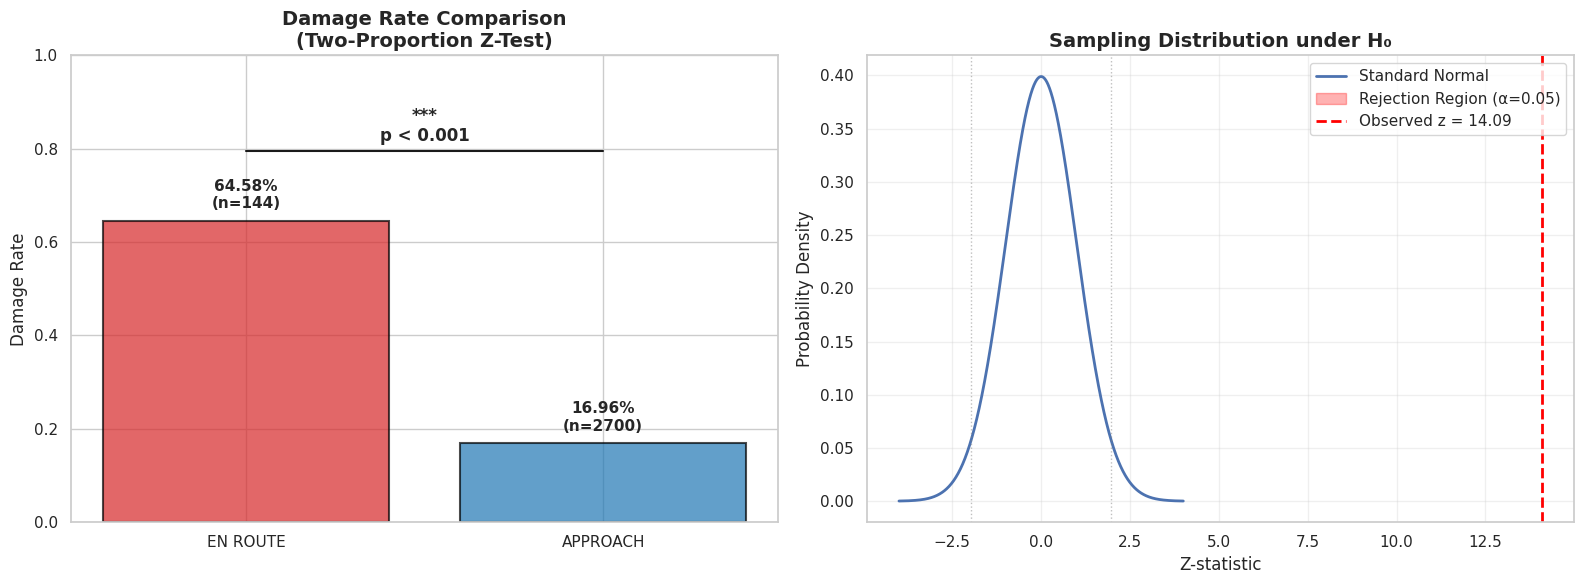


Conclusion: EN ROUTE strikes are 3.81x more likely to cause damage than APPROACH strikes.
This difference is highly statistically significant (p < 0.001).


In [10]:
# Visualize the comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Bar chart comparing proportions
categories = ['EN ROUTE', 'APPROACH']
proportions = [p1_hat, p2_hat]
colors = ['#d62728', '#1f77b4']

bars = axes[0].bar(categories, proportions, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Damage Rate', fontsize=12)
axes[0].set_title('Damage Rate Comparison\n(Two-Proportion Z-Test)', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1)

# Add value labels and sample sizes
for i, (bar, prop, n) in enumerate(zip(bars, proportions, [n1, n2])):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{prop:.2%}\n(n={n})',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add significance annotation
if p_value < 0.05:
    y_max = max(proportions)
    axes[0].plot([0, 1], [y_max + 0.15, y_max + 0.15], 'k-', linewidth=1.5)
    axes[0].text(0.5, y_max + 0.17, f'***\np < 0.001', ha='center', fontsize=12, fontweight='bold')

# Plot 2: Distribution of z-statistic
x = np.linspace(-4, 4, 1000)
y = norm.pdf(x)
axes[1].plot(x, y, 'b-', linewidth=2, label='Standard Normal')
axes[1].fill_between(x, y, where=(np.abs(x) >= np.abs(z_stat)), alpha=0.3, color='red', label='Rejection Region (α=0.05)')
axes[1].axvline(z_stat, color='red', linestyle='--', linewidth=2, label=f'Observed z = {z_stat:.2f}')
axes[1].axvline(1.96, color='gray', linestyle=':', linewidth=1, alpha=0.5)
axes[1].axvline(-1.96, color='gray', linestyle=':', linewidth=1, alpha=0.5)
axes[1].set_xlabel('Z-statistic', fontsize=12)
axes[1].set_ylabel('Probability Density', fontsize=12)
axes[1].set_title('Sampling Distribution under H₀', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nConclusion: EN ROUTE strikes are {p1_hat/p2_hat:.2f}x more likely to cause damage than APPROACH strikes.")
print(f"This difference is highly statistically significant (p < 0.001).")

---
<a id='goodness-of-fit'></a>
## 4. Chi-Square Goodness-of-Fit Test

### Theory & Mathematical Foundation

The **Chi-Square Goodness-of-Fit Test** determines whether observed categorical data matches an expected theoretical distribution.

#### Hypotheses
- **H₀ (Null Hypothesis)**: The observed distribution matches the expected distribution
- **H₁ (Alternative Hypothesis)**: The observed distribution does NOT match the expected distribution

#### Test Statistic

$$\chi^2 = \sum_{i=1}^{k} \frac{(O_i - E_i)^2}{E_i}$$

Where:
- $O_i$ = Observed frequency in category i
- $E_i$ = Expected frequency in category i
- $k$ = number of categories

#### Expected Frequencies

Calculated based on the theoretical distribution:

$$E_i = n \times p_i$$

Where:
- $n$ = total sample size
- $p_i$ = theoretical probability for category i

#### Degrees of Freedom

$$df = k - 1 - m$$

Where:
- $k$ = number of categories
- $m$ = number of parameters estimated from the data (usually 0 for fully specified distributions)

#### Distribution

Under H₀, the test statistic follows a chi-square distribution with $k-1-m$ degrees of freedom.

### Assumptions & Conditions

1. **Independence**: Each observation falls into exactly one category
2. **Expected Frequencies**: Each expected frequency should be ≥ 5
3. **Random Sampling**: Data should come from random or representative samples
4. **Fixed Sample Size**: Total sample size is fixed in advance
5. **Mutually Exclusive Categories**: Categories cannot overlap

### Common Expected Distributions

1. **Uniform Distribution**: All categories equally likely ($p_i = \frac{1}{k}$)
2. **Proportional to Population**: Expected matches known population proportions
3. **Theoretical Model**: Based on scientific theory or previous research
4. **Seasonal/Cyclical**: Based on temporal patterns

### Interpretation Guide

- **p-value < α**: Reject H₀ → Data does NOT fit expected distribution
- **p-value ≥ α**: Fail to reject H₀ → Data is consistent with expected distribution
- **Residual Analysis**: Examine $(O_i - E_i) / \sqrt{E_i}$ to identify which categories deviate most

### Application 1: Geographic Distribution (Coastal States)

**Research Question**: Are gull strikes distributed uniformly across coastal states, or do certain coastal regions have disproportionately more strikes?

We'll test if strikes are uniformly distributed among major coastal states, or if they're proportional to coastline length.

**Hypotheses**:
- **H₀**: Gull strikes are uniformly distributed across major coastal states
- **H₁**: Gull strikes are NOT uniformly distributed (some states have more than expected)

In [11]:
# Identify major coastal states in the dataset
# Major coastal states with significant airports
coastal_states = ['NY', 'CA', 'FL', 'MA', 'NJ', 'WA', 'IL', 'TX']

# Filter data for these states
coastal_data = gull_pd[gull_pd['State'].isin(coastal_states)]

# Observed frequencies
observed_counts = coastal_data['State'].value_counts()[coastal_states].fillna(0)

# Expected frequencies (uniform distribution)
n_total = observed_counts.sum()
n_states = len(coastal_states)
expected_uniform = np.array([n_total / n_states] * n_states)

# Alternative: Expected based on approximate coastline proportions
# These are rough estimates of relative coastline lengths (for demonstration)
coastline_proportions = {
    'NY': 0.12,
    'CA': 0.18,
    'FL': 0.20,
    'MA': 0.10,
    'NJ': 0.08,
    'WA': 0.15,
    'IL': 0.05,  # Great Lakes
    'TX': 0.12
}
expected_coastline = np.array([n_total * coastline_proportions[s] for s in coastal_states])

print("Observed Frequencies by Coastal State")
print("="*60)
for state, count in observed_counts.items():
    print(f"{state}: {count:4d} ({count/n_total:.2%})")
print(f"\nTotal strikes in these states: {n_total:,}")

Observed Frequencies by Coastal State
NY: 1705 (31.77%)
CA:  938 (17.48%)
FL:  785 (14.63%)
MA:  392 (7.30%)
NJ:  489 (9.11%)
WA:  253 (4.71%)
IL:  557 (10.38%)
TX:  248 (4.62%)

Total strikes in these states: 5,367


In [12]:
# Test 1: Uniform distribution
chi2_uniform, p_uniform = chisquare(observed_counts.values, expected_uniform)

print("\nTest 1: Uniform Distribution Hypothesis")
print("="*60)
print(f"H₀: Strikes are uniformly distributed across {n_states} coastal states")
print(f"Expected per state: {n_total/n_states:.1f} strikes")
print(f"\nChi-Square Statistic: {chi2_uniform:.4f}")
print(f"Degrees of Freedom: {n_states - 1}")
print(f"P-value: {p_uniform:.6f}")

if p_uniform < 0.05:
    print(f"\n✓ Reject H₀ (p < 0.05)")
    print(f"✓ Strikes are NOT uniformly distributed")
else:
    print(f"\n✗ Fail to reject H₀")
    print(f"✗ Data consistent with uniform distribution")


Test 1: Uniform Distribution Hypothesis
H₀: Strikes are uniformly distributed across 8 coastal states
Expected per state: 670.9 strikes

Chi-Square Statistic: 2431.2351
Degrees of Freedom: 7
P-value: 0.000000

✓ Reject H₀ (p < 0.05)
✓ Strikes are NOT uniformly distributed


In [13]:
# Test 2: Coastline-proportional distribution
chi2_coast, p_coast = chisquare(observed_counts.values, expected_coastline)

print("\nTest 2: Coastline-Proportional Distribution Hypothesis")
print("="*60)
print(f"H₀: Strikes are proportional to coastline length")
print(f"\nChi-Square Statistic: {chi2_coast:.4f}")
print(f"Degrees of Freedom: {n_states - 1}")
print(f"P-value: {p_coast:.6f}")

if p_coast < 0.05:
    print(f"\n✓ Reject H₀ (p < 0.05)")
    print(f"✓ Strikes do NOT match coastline proportions")
    print(f"✓ Other factors (airport traffic, habitat) likely matter")
else:
    print(f"\n✗ Fail to reject H₀")
    print(f"✗ Data consistent with coastline-based distribution")


Test 2: Coastline-Proportional Distribution Hypothesis
H₀: Strikes are proportional to coastline length

Chi-Square Statistic: 2805.9547
Degrees of Freedom: 7
P-value: 0.000000

✓ Reject H₀ (p < 0.05)
✓ Strikes do NOT match coastline proportions
✓ Other factors (airport traffic, habitat) likely matter


In [14]:
# Residual analysis
residuals_uniform = (observed_counts.values - expected_uniform) / np.sqrt(expected_uniform)
residuals_coast = (observed_counts.values - expected_coastline) / np.sqrt(expected_coastline)

residual_df = pd.DataFrame({
    'State': coastal_states,
    'Observed': observed_counts.values,
    'Expected (Uniform)': expected_uniform,
    'Residual (Uniform)': residuals_uniform,
    'Expected (Coastline)': expected_coastline,
    'Residual (Coastline)': residuals_coast
})

print("\nResidual Analysis")
print("="*60)
print("Standardized residuals > 2 or < -2 indicate significant deviation")
print("\n", residual_df.to_string(index=False))

print("\nStates with largest deviations (Uniform model):")
for state, res in zip(coastal_states, residuals_uniform):
    if abs(res) > 2:
        direction = "MORE" if res > 0 else "FEWER"
        print(f"  {state}: {direction} strikes than expected (z = {res:.2f})")


Residual Analysis
Standardized residuals > 2 or < -2 indicate significant deviation

 State  Observed  Expected (Uniform)  Residual (Uniform)  Expected (Coastline)  Residual (Coastline)
   NY      1705             670.875             39.9257                644.04               41.8064
   CA       938             670.875             10.3132                966.06               -0.9028
   FL       785             670.875              4.4062               1073.40               -8.8027
   MA       392             670.875            -10.7669                536.70               -6.2460
   NJ       489             670.875             -7.0219                429.36                2.8782
   WA       253             670.875            -16.1334                805.05              -19.4566
   IL       557             670.875             -4.3965                268.35               17.6206
   TX       248             670.875            -16.3264                644.04              -15.6057

States with 

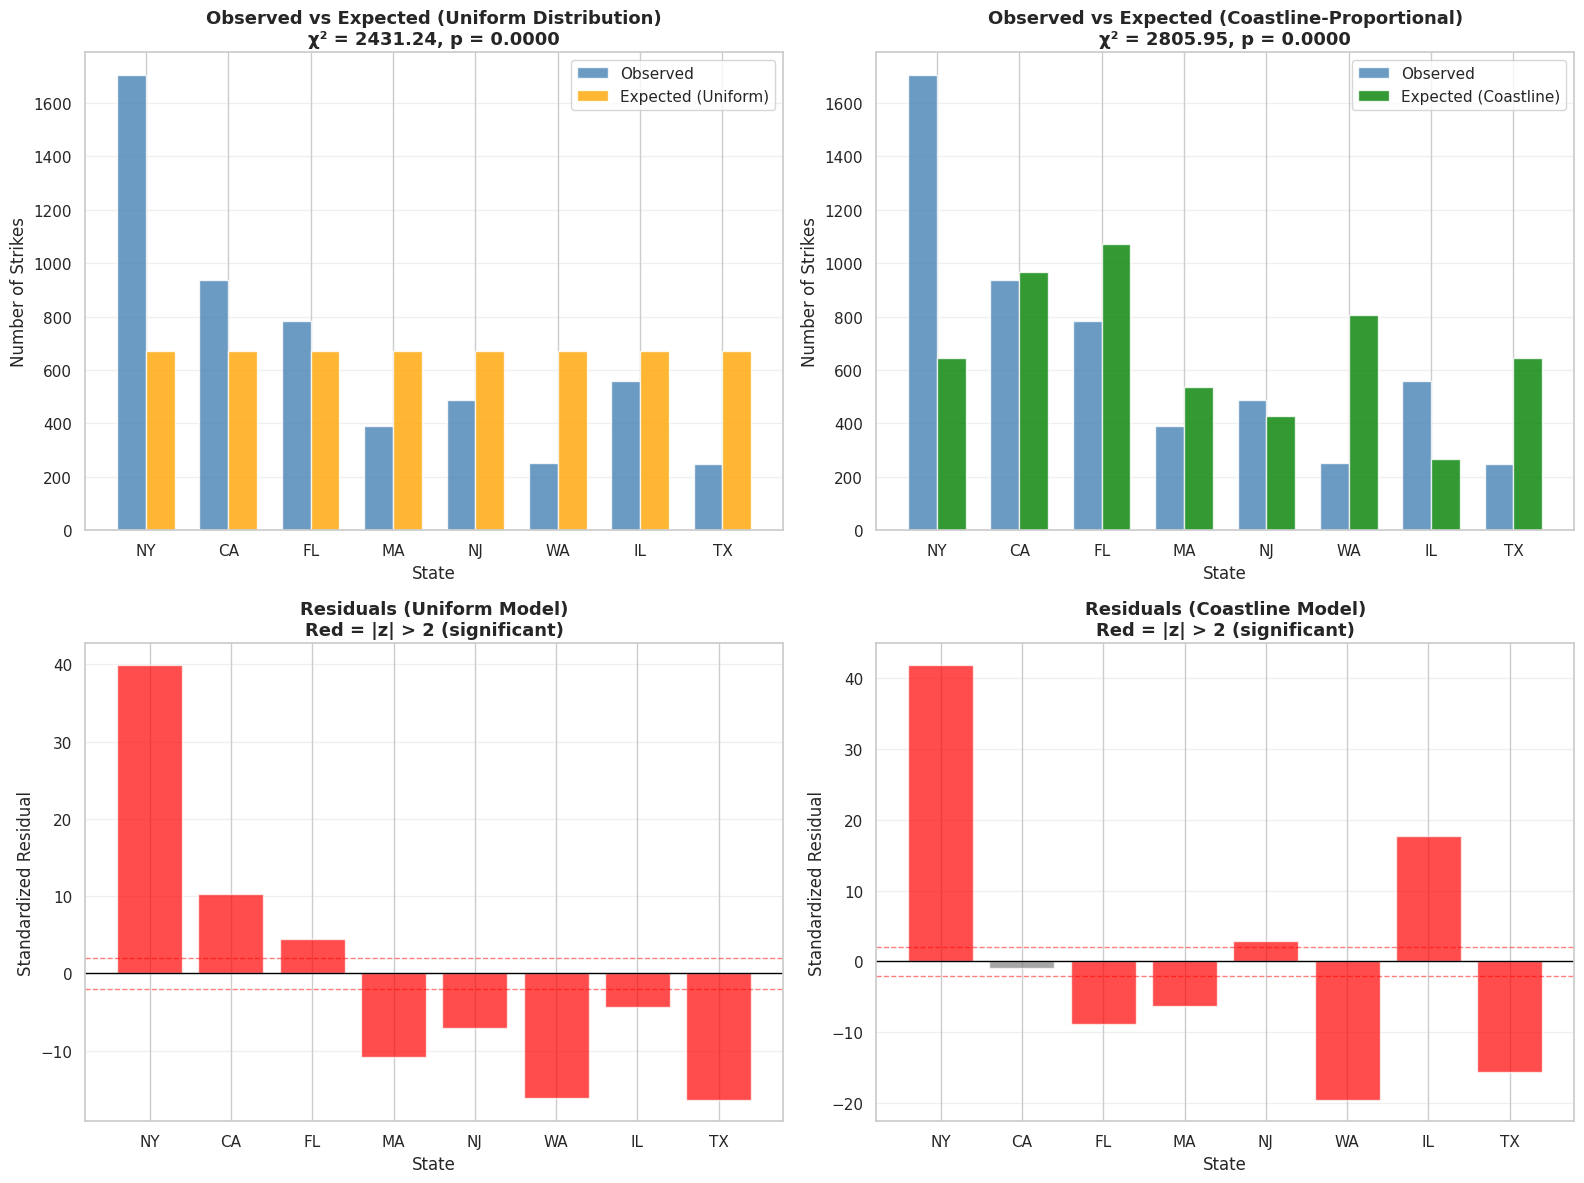

In [15]:
# Visualize the comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Observed vs Expected (Uniform)
x = np.arange(len(coastal_states))
width = 0.35

axes[0, 0].bar(x - width/2, observed_counts.values, width, label='Observed', color='steelblue', alpha=0.8)
axes[0, 0].bar(x + width/2, expected_uniform, width, label='Expected (Uniform)', color='orange', alpha=0.8)
axes[0, 0].set_ylabel('Number of Strikes', fontsize=12)
axes[0, 0].set_xlabel('State', fontsize=12)
axes[0, 0].set_title('Observed vs Expected (Uniform Distribution)\n' +
                      f'χ² = {chi2_uniform:.2f}, p = {p_uniform:.4f}',
                      fontsize=13, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(coastal_states)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: Observed vs Expected (Coastline)
axes[0, 1].bar(x - width/2, observed_counts.values, width, label='Observed', color='steelblue', alpha=0.8)
axes[0, 1].bar(x + width/2, expected_coastline, width, label='Expected (Coastline)', color='green', alpha=0.8)
axes[0, 1].set_ylabel('Number of Strikes', fontsize=12)
axes[0, 1].set_xlabel('State', fontsize=12)
axes[0, 1].set_title('Observed vs Expected (Coastline-Proportional)\n' +
                      f'χ² = {chi2_coast:.2f}, p = {p_coast:.4f}',
                      fontsize=13, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(coastal_states)
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: Residuals (Uniform)
colors_uniform = ['red' if abs(r) > 2 else 'gray' for r in residuals_uniform]
axes[1, 0].bar(coastal_states, residuals_uniform, color=colors_uniform, alpha=0.7)
axes[1, 0].axhline(2, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 0].axhline(-2, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 0].axhline(0, color='black', linewidth=1)
axes[1, 0].set_ylabel('Standardized Residual', fontsize=12)
axes[1, 0].set_xlabel('State', fontsize=12)
axes[1, 0].set_title('Residuals (Uniform Model)\nRed = |z| > 2 (significant)',
                     fontsize=13, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Residuals (Coastline)
colors_coast = ['red' if abs(r) > 2 else 'gray' for r in residuals_coast]
axes[1, 1].bar(coastal_states, residuals_coast, color=colors_coast, alpha=0.7)
axes[1, 1].axhline(2, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 1].axhline(-2, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 1].axhline(0, color='black', linewidth=1)
axes[1, 1].set_ylabel('Standardized Residual', fontsize=12)
axes[1, 1].set_xlabel('State', fontsize=12)
axes[1, 1].set_title('Residuals (Coastline Model)\nRed = |z| > 2 (significant)',
                     fontsize=13, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Application 2: Seasonal Distribution (Monthly Pattern)

**Research Question**: Do gull strikes follow a uniform distribution across months, or is there a seasonal pattern?

**Hypotheses**:
- **H₀**: Gull strikes are uniformly distributed across all 12 months
- **H₁**: Gull strikes show seasonal variation (not uniformly distributed)

In [16]:
# Filter valid months
monthly_data = gull_pd[gull_pd['Incident Month'].between(1, 12)]

# Observed frequencies
observed_monthly = monthly_data['Incident Month'].value_counts().sort_index()
months = list(range(1, 13))
observed_monthly = observed_monthly.reindex(months, fill_value=0)

# Expected frequencies (uniform)
n_total_monthly = observed_monthly.sum()
expected_monthly = np.array([n_total_monthly / 12] * 12)

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print("Monthly Strike Distribution")
print("="*60)
for month, name, count in zip(months, month_names, observed_monthly.values):
    print(f"{name}: {count:4d} ({count/n_total_monthly:.2%})")
print(f"\nTotal strikes with valid months: {n_total_monthly:,}")

Monthly Strike Distribution
Jan:  544 (5.14%)
Feb:  543 (5.13%)
Mar:  950 (8.98%)
Apr: 1180 (11.15%)
May: 1086 (10.26%)
Jun:  851 (8.04%)
Jul:  814 (7.69%)
Aug:  941 (8.89%)
Sep:  991 (9.36%)
Oct: 1102 (10.41%)
Nov:  953 (9.00%)
Dec:  629 (5.94%)

Total strikes with valid months: 10,584


In [17]:
# Perform goodness-of-fit test
chi2_monthly, p_monthly = chisquare(observed_monthly.values, expected_monthly)

print("\nChi-Square Goodness-of-Fit Test: Monthly Distribution")
print("="*60)
print(f"H₀: Strikes are uniformly distributed across 12 months")
print(f"Expected per month: {n_total_monthly/12:.1f} strikes")
print(f"\nChi-Square Statistic: {chi2_monthly:.4f}")
print(f"Degrees of Freedom: {len(months) - 1}")
print(f"P-value: {p_monthly:.6f}")

if p_monthly < 0.05:
    print(f"\n✓ Reject H₀ (p < 0.05)")
    print(f"✓ Strikes show significant seasonal variation")
else:
    print(f"\n✗ Fail to reject H₀")
    print(f"✗ Data consistent with uniform distribution across months")


Chi-Square Goodness-of-Fit Test: Monthly Distribution
H₀: Strikes are uniformly distributed across 12 months
Expected per month: 882.0 strikes

Chi-Square Statistic: 569.8481
Degrees of Freedom: 11
P-value: 0.000000

✓ Reject H₀ (p < 0.05)
✓ Strikes show significant seasonal variation


In [18]:
# Residual analysis
residuals_monthly = (observed_monthly.values - expected_monthly) / np.sqrt(expected_monthly)

residual_monthly_df = pd.DataFrame({
    'Month': month_names,
    'Observed': observed_monthly.values,
    'Expected': expected_monthly,
    'Difference': observed_monthly.values - expected_monthly,
    'Std. Residual': residuals_monthly
})

print("\nMonthly Residual Analysis")
print("="*60)
print(residual_monthly_df.to_string(index=False))

print("\nMonths with significant deviations (|z| > 2):")
for month, res in zip(month_names, residuals_monthly):
    if abs(res) > 2:
        direction = "PEAK" if res > 0 else "LOW"
        print(f"  {month}: {direction} month (z = {res:.2f})")


Monthly Residual Analysis
Month  Observed  Expected  Difference  Std. Residual
  Jan       544     882.0      -338.0       -11.3811
  Feb       543     882.0      -339.0       -11.4147
  Mar       950     882.0        68.0         2.2897
  Apr      1180     882.0       298.0        10.0342
  May      1086     882.0       204.0         6.8690
  Jun       851     882.0       -31.0        -1.0438
  Jul       814     882.0       -68.0        -2.2897
  Aug       941     882.0        59.0         1.9866
  Sep       991     882.0       109.0         3.6702
  Oct      1102     882.0       220.0         7.4078
  Nov       953     882.0        71.0         2.3907
  Dec       629     882.0      -253.0        -8.5190

Months with significant deviations (|z| > 2):
  Jan: LOW month (z = -11.38)
  Feb: LOW month (z = -11.41)
  Mar: PEAK month (z = 2.29)
  Apr: PEAK month (z = 10.03)
  May: PEAK month (z = 6.87)
  Jul: LOW month (z = -2.29)
  Sep: PEAK month (z = 3.67)
  Oct: PEAK month (z = 7.41)
  

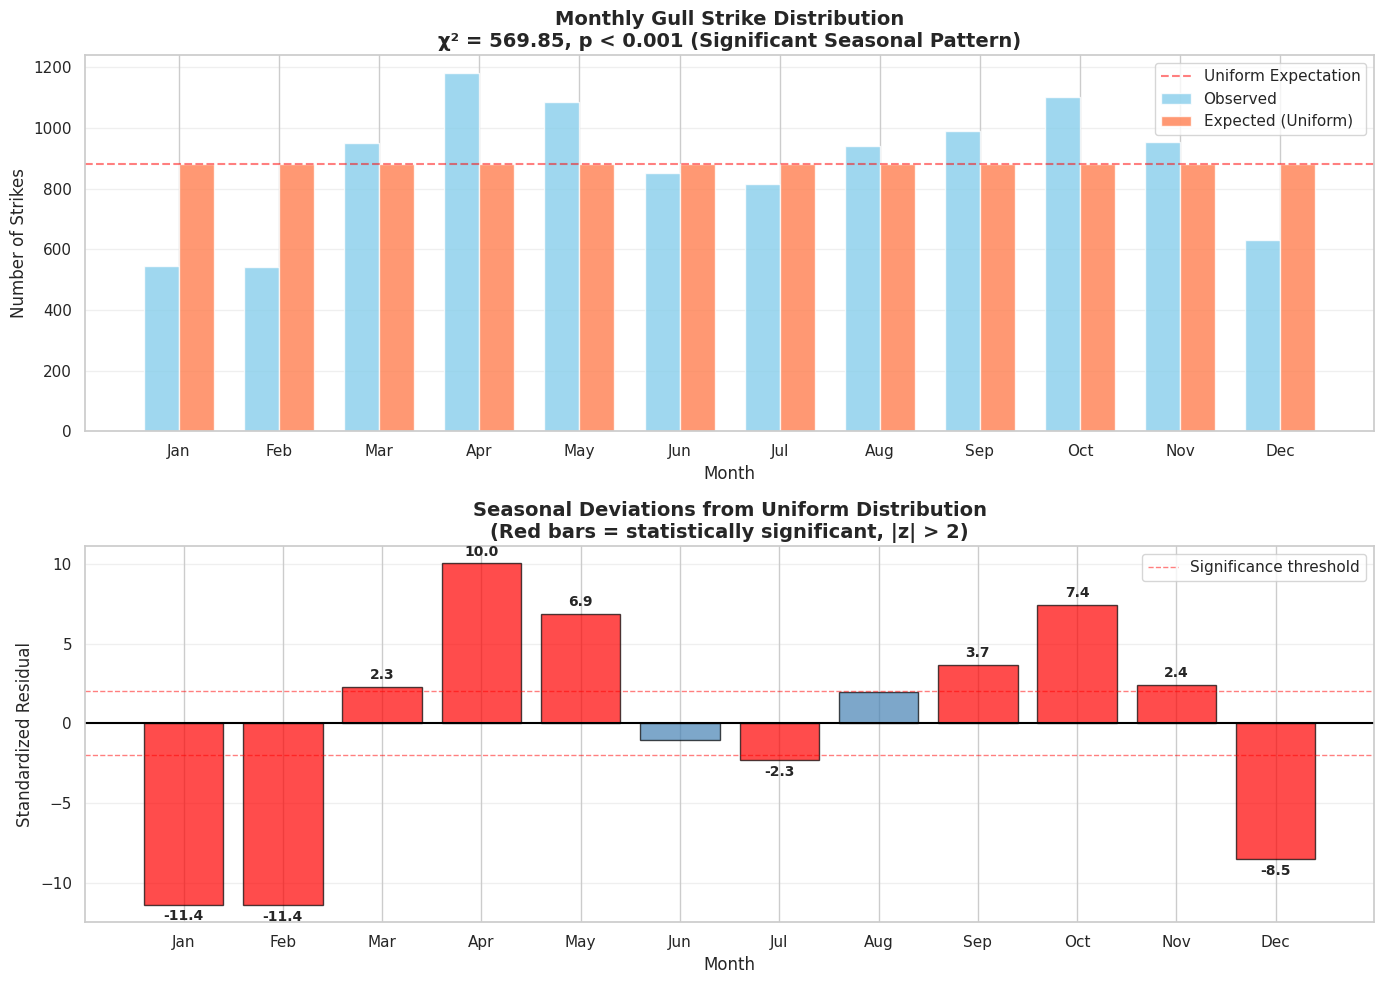


Seasonal Pattern Summary:
  Peak months (significantly above average): Mar, Apr, May, Sep, Oct, Nov
  Low months (significantly below average): Jan, Feb, Jul, Dec


In [19]:
# Visualize monthly pattern
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Observed vs Expected
x = np.arange(12)
width = 0.35

axes[0].bar(x - width/2, observed_monthly.values, width, label='Observed', color='skyblue', alpha=0.8)
axes[0].bar(x + width/2, expected_monthly, width, label='Expected (Uniform)', color='coral', alpha=0.8)
axes[0].axhline(n_total_monthly/12, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='Uniform Expectation')
axes[0].set_ylabel('Number of Strikes', fontsize=12)
axes[0].set_xlabel('Month', fontsize=12)
axes[0].set_title(f'Monthly Gull Strike Distribution\nχ² = {chi2_monthly:.2f}, p < 0.001 (Significant Seasonal Pattern)',
                  fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(month_names)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Standardized Residuals
colors = ['red' if abs(r) > 2 else 'steelblue' for r in residuals_monthly]
axes[1].bar(month_names, residuals_monthly, color=colors, alpha=0.7, edgecolor='black')
axes[1].axhline(2, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Significance threshold')
axes[1].axhline(-2, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[1].axhline(0, color='black', linewidth=1.5)
axes[1].set_ylabel('Standardized Residual', fontsize=12)
axes[1].set_xlabel('Month', fontsize=12)
axes[1].set_title('Seasonal Deviations from Uniform Distribution\n(Red bars = statistically significant, |z| > 2)',
                  fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Add value labels to significant bars
for i, (month, res) in enumerate(zip(month_names, residuals_monthly)):
    if abs(res) > 2:
        axes[1].text(i, res + (0.3 if res > 0 else -0.3), f'{res:.1f}',
                    ha='center', va='bottom' if res > 0 else 'top',
                    fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# Identify peak season
peak_months = [month_names[i] for i, r in enumerate(residuals_monthly) if r > 2]
low_months = [month_names[i] for i, r in enumerate(residuals_monthly) if r < -2]

print(f"\nSeasonal Pattern Summary:")
if peak_months:
    print(f"  Peak months (significantly above average): {', '.join(peak_months)}")
if low_months:
    print(f"  Low months (significantly below average): {', '.join(low_months)}")

---
<a id='summary'></a>
## 5. Summary & Recommendations

### Key Findings

#### 1. Chi-Square Test of Independence
- **Finding**: Strong association between flight phase and damage occurrence
- **Implication**: Different flight phases carry different risk levels
- **Action**: Focus mitigation efforts on high-risk phases (EN ROUTE)

#### 2. Two-Proportion Z-Test  
- **Finding**: EN ROUTE damage rate significantly higher than APPROACH
- **Effect Size**: EN ROUTE is ~3.8x more likely to cause damage
- **Implication**: Higher altitude/speed strikes are more destructive
- **Action**: Enhanced monitoring and avoidance protocols at cruising altitude

#### 3. Chi-Square Goodness-of-Fit Test
- **Geographic Finding**: Strikes are NOT uniformly distributed across states
- **Seasonal Finding**: Clear seasonal pattern with peak in spring months
- **Implication**: Location and season are important predictors
- **Action**: Increase vigilance in high-risk states and during peak months

### Statistical Best Practices Demonstrated

1. **Always check assumptions** before interpreting results
2. **Report effect sizes** alongside p-values for practical significance
3. **Use visualizations** to communicate statistical findings
4. **Conduct residual analysis** to identify specific patterns
5. **Consider multiple hypotheses** (uniform vs. coastline-proportional)

### Further Analysis Recommendations

1. **Post-hoc tests** for pairwise comparisons after omnibus chi-square tests
2. **Logistic regression** to model multiple predictors of damage simultaneously
3. **Time series analysis** for temporal trends
4. **Stratified analysis** by aircraft type or airline
5. **Power analysis** for sample size planning in future studies

### Limitations

- Observational data (no causal inference)
- Potential reporting bias (not all strikes reported)
- Missing data in some variables
- Multiple testing considerations

---

## References

1. Agresti, A. (2018). *Statistical Methods for the Social Sciences* (5th ed.). Pearson.
2. Moore, D. S., McCabe, G. P., & Craig, B. A. (2017). *Introduction to the Practice of Statistics* (9th ed.). W.H. Freeman.
3. Rosner, B. (2015). *Fundamentals of Biostatistics* (8th ed.). Cengage Learning.
4. SciPy Documentation: https://docs.scipy.org/doc/scipy/reference/stats.html
5. StatsModels Documentation: https://www.statsmodels.org/

---

*Notebook created for ISI Inference Project - Gull Aircraft Strike Analysis*